# Early-Exercise-Premium and Financially Constrained Models

## Residual learning for American put option pricing

**SoftUni Deep Learning Final Project**  
**Author:** Kamen Dimitrov  
**Notebook:** `05_early_exercise_premium_model.ipynb`

---

This notebook tests the central modeling proposition of the project: the neural network may learn American put values more effectively when it predicts only the value created by early exercise rather than relearning the complete option-pricing function.

The notebook compares the direct MLP from Notebook 04 with three residual formulations:

1. an unconstrained early-exercise-premium model;
2. a non-negative early-exercise-premium model;
3. a fully constrained residual model built above the maximum of European and intrinsic value.

All models use the same five input features, frozen production splits, feature scaler, hidden-layer capacity, and evaluation framework. This isolates the effect of target design and financial constraints.

# 1. Research objective and hypotheses

The American value can be written as

$$
V_A = V_E + EEP,
$$

where

$$
EEP = V_A - V_E \geq 0.
$$

The direct MLP learns $(V_A/K\). The premium model instead learns

$$
y_{EEP}=\frac{V_A-V_E}{K}.
$$

The fully constrained model uses the financial floor

$$
F=\max(V_E,\max(K-S,0))
$$

and learns

$$
y_F=\frac{V_A-F}{K}.
$$

With a `Softplus` output, the reconstructed price satisfies all three lower bounds by construction.

This notebook evaluates:

- **H2 — Premium decomposition**;
- **H3 — Financial constraints**.

In [1]:
from pathlib import Path
import json
import sys
import time

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.torch_datasets import (
    AmericanOptionDataset,
    FEATURE_COLUMNS,
    LoaderConfig,
    create_regression_loader,
    load_feature_scaler,
    read_parquet_components,
)
from src.evaluation.model_comparison import (
    build_model_comparison_table,
    decide_h2_premium_decomposition,
    decide_h3_financial_constraints,
    premium_error_metrics,
)
from src.evaluation.regression_metrics import regression_metrics
from src.models.direct_pricer import DirectAmericanPutMLP, DirectMLPConfig
from src.models.premium_pricer import PremiumAmericanPutMLP, PremiumMLPConfig
from src.training.checkpointing import load_checkpoint, save_json
from src.training.losses import (
    PremiumWeightConfig,
    WeightedSmoothL1Loss,
    apply_premium_weighting,
    fit_premium_weighting,
)
from src.training.loops import (
    TrainingConfig,
    fit_regression_model,
    predict_regression_model,
    set_global_seed,
)

In [2]:
DATA_DIR = PROJECT_ROOT / "data" / "generated"
DIRECT_ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "direct_mlp"
PREMIUM_ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "premium_models"
PREMIUM_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

CORE_PATHS = [
    DATA_DIR / "american_put_core.parquet",
    DATA_DIR / "american_put_boundary.parquet",
]
OOD_PATHS = {
    "high_volatility": DATA_DIR / "american_put_ood_high_volatility.parquet",
    "extreme_moneyness": DATA_DIR / "american_put_ood_extreme_moneyness.parquet",
    "long_maturity": DATA_DIR / "american_put_ood_long_maturity.parquet",
    "rate_dividend": DATA_DIR / "american_put_ood_rate_dividend.parquet",
}
DIRECT_CHECKPOINT_PATH = DIRECT_ARTIFACT_DIR / "best_direct_mlp.pt"
SCALER_PATH = DIRECT_ARTIFACT_DIR / "feature_scaler.joblib"

SEED = 42
FAST_DEV_MODE = False
TRAIN_LIMIT = 100_000 if FAST_DEV_MODE else None
VALIDATION_LIMIT = 25_000 if FAST_DEV_MODE else None
TEST_LIMIT = 25_000 if FAST_DEV_MODE else None

set_global_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


# 2. Dependency and split validation

Notebook 05 requires the production Parquet files and the Step 4 direct-model artifacts. The feature scaler is reused so the model comparison does not introduce a second preprocessing regime.

In [5]:
required_paths = [*CORE_PATHS, *OOD_PATHS.values(), DIRECT_CHECKPOINT_PATH, SCALER_PATH]
missing = [path for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Notebook 05 prerequisites are missing:\n"
        + "\n".join(f"- {path}" for path in missing)
    )

MODEL_COLUMNS = [
    "sample_id", "component", "split", *FEATURE_COLUMNS,
    "normalized_american_price", "normalized_european_price",
    "normalized_early_exercise_premium", "strike", "intrinsic_value",
    "european_price", "american_price", "moneyness", "exercise_now",
    "boundary_distance_normalized",
]

train_frame = read_parquet_components(
    CORE_PATHS, columns=MODEL_COLUMNS, split="train", row_limit=TRAIN_LIMIT
)
validation_frame = read_parquet_components(
    CORE_PATHS, columns=MODEL_COLUMNS, split="validation", row_limit=VALIDATION_LIMIT
)
test_frame = read_parquet_components(
    CORE_PATHS, columns=MODEL_COLUMNS, split="test", row_limit=TEST_LIMIT
)

for frame in (train_frame, validation_frame, test_frame):
    frame["normalized_intrinsic_value"] = frame["intrinsic_value"] / frame["strike"]
    frame["normalized_financial_floor"] = np.maximum(
        frame["normalized_european_price"], frame["normalized_intrinsic_value"]
    )
    frame["normalized_floor_residual"] = (
        frame["normalized_american_price"] - frame["normalized_financial_floor"]
    ).clip(lower=0.0)

pd.DataFrame({
    "observations": [len(train_frame), len(validation_frame), len(test_frame)],
    "exercise_rate": [
        train_frame["exercise_now"].mean(),
        validation_frame["exercise_now"].mean(),
        test_frame["exercise_now"].mean(),
    ],
}, index=["train", "validation", "test"])

,observations,exercise_rate
train,874512,0.239707
validation,187677,0.239523
test,187811,0.240454


# 3. Premium-target distribution

The premium target is structurally imbalanced because many contracts have little or no economic benefit from immediate exercise. A zero-premium predictor is therefore a mandatory baseline.

In [6]:
premium_summary = train_frame["normalized_early_exercise_premium"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)
premium_summary.to_frame("normalized premium")

,normalized premium
count,874512.000000
mean,0.013320
std,0.023708
min,0.000000
50%,0.002773
75%,0.014564
90%,0.042704
95%,0.066720
99%,0.112333
max,0.193458


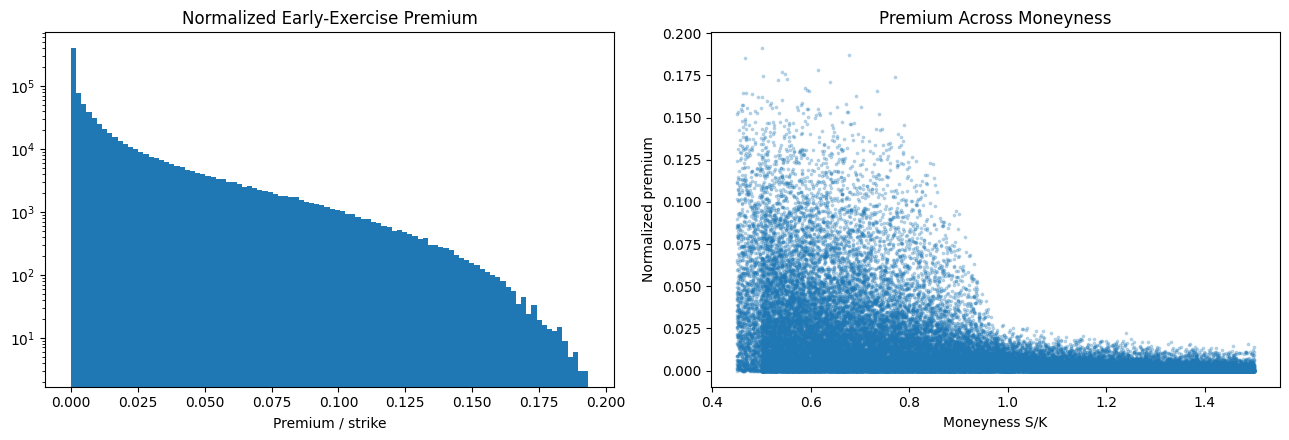

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(
    train_frame["normalized_early_exercise_premium"],
    bins=100,
)
axes[0].set_title("Normalized Early-Exercise Premium")
axes[0].set_xlabel("Premium / strike")
axes[0].set_yscale("log")

axes[1].scatter(
    train_frame["moneyness"].sample(min(50_000, len(train_frame)), random_state=SEED),
    train_frame["normalized_early_exercise_premium"].sample(
        min(50_000, len(train_frame)), random_state=SEED
    ),
    s=3,
    alpha=0.25,
)
axes[1].set_xlabel("Moneyness S/K")
axes[1].set_ylabel("Normalized premium")
axes[1].set_title("Premium Across Moneyness")
plt.tight_layout()
plt.show()

# 4. Direct-model and trivial baselines

The comparison includes:

- zero premium, equivalent to using the European value;
- mean training premium;
- the direct MLP from Notebook 04.

In [8]:
feature_scaler = load_feature_scaler(SCALER_PATH)
LOADER_CONFIG = LoaderConfig(batch_size=1024, num_workers=0, pin_memory=True, seed=SEED)

def make_dataset_loader(frame, target_column, *, weight_column=None, shuffle=False, drop_last=False):
    dataset = AmericanOptionDataset(
        frame,
        scaler=feature_scaler,
        target_column=target_column,
        weight_column=weight_column,
    )
    loader = create_regression_loader(
        dataset,
        config=LOADER_CONFIG,
        shuffle=shuffle,
        drop_last=drop_last,
    )
    return dataset, loader

direct_checkpoint = load_checkpoint(DIRECT_CHECKPOINT_PATH, map_location=DEVICE)
direct_cfg_raw = direct_checkpoint["model_config"]
direct_config = DirectMLPConfig(
    input_features=int(direct_cfg_raw["input_features"]),
    hidden_sizes=tuple(direct_cfg_raw["hidden_sizes"]),
    batch_norm_after=tuple(direct_cfg_raw["batch_norm_after"]),
    output_activation=direct_cfg_raw["output_activation"],
)
direct_model = DirectAmericanPutMLP(direct_config).to(DEVICE)
direct_model.load_state_dict(direct_checkpoint["model_state_dict"])

_, direct_test_loader = make_dataset_loader(
    test_frame, "normalized_american_price", shuffle=False
)
direct_prediction = predict_regression_model(
    direct_model, direct_test_loader, device=DEVICE
).rename(columns={"prediction": "direct_mlp"})
test_frame = test_frame.merge(
    direct_prediction[["sample_id", "direct_mlp"]],
    on="sample_id",
    validate="one_to_one",
)

mean_training_premium = float(
    train_frame["normalized_early_exercise_premium"].mean()
)
test_frame["zero_premium_baseline"] = test_frame["normalized_european_price"]
test_frame["mean_premium_baseline"] = (
    test_frame["normalized_european_price"] + mean_training_premium
)

# 5. Candidate definitions and weighted-loss ablation

Five candidates are trained with equal hidden-layer capacity:

1. unconstrained premium with linear output;
2. non-negative premium with `Softplus` output;
3. financial-floor residual with unweighted loss;
4. financial-floor residual with premium-magnitude weighting;
5. financial-floor residual with boundary-aware weighting.

Only the best floor-residual configuration by validation loss proceeds as the final constrained model.

In [9]:
CANDIDATES = {
    "unconstrained_premium": {
        "target": "normalized_early_exercise_premium",
        "residual_base": "european",
        "activation": "linear",
        "weight_mode": "unweighted",
    },
    "nonnegative_premium": {
        "target": "normalized_early_exercise_premium",
        "residual_base": "european",
        "activation": "softplus",
        "weight_mode": "unweighted",
    },
    "floor_residual_unweighted": {
        "target": "normalized_floor_residual",
        "residual_base": "financial_floor",
        "activation": "softplus",
        "weight_mode": "unweighted",
    },
    "floor_residual_magnitude": {
        "target": "normalized_floor_residual",
        "residual_base": "financial_floor",
        "activation": "softplus",
        "weight_mode": "magnitude",
    },
    "floor_residual_boundary": {
        "target": "normalized_floor_residual",
        "residual_base": "financial_floor",
        "activation": "softplus",
        "weight_mode": "boundary",
    },
}

TRAINING_CONFIG = TrainingConfig(
    epochs=100,
    learning_rate=1e-3,
    weight_decay=1e-5,
    early_stopping_patience=10,
    scheduler_patience=4,
    scheduler_factor=0.5,
    min_learning_rate=1e-6,
    gradient_clip_norm=1.0,
    mixed_precision=True,
    seed=SEED,
)
WEIGHT_CONFIG = PremiumWeightConfig()
loss_fn = WeightedSmoothL1Loss(beta=1.0)

In [10]:
candidate_results = {}

for candidate_name, specification in CANDIDATES.items():
    print(f"\n=== {candidate_name} ===")
    target_column = specification["target"]
    weight_mode = specification["weight_mode"]
    train_work = train_frame.copy()
    validation_work = validation_frame.copy()
    weight_column = None

    fitted_weighting = fit_premium_weighting(
        train_work,
        target_column=target_column,
        mode=weight_mode,
        config=WEIGHT_CONFIG,
    )
    if weight_mode != "unweighted":
        weight_column = "training_weight"
        train_work[weight_column] = apply_premium_weighting(
            train_work, fitted=fitted_weighting
        )
        validation_work[weight_column] = apply_premium_weighting(
            validation_work, fitted=fitted_weighting
        )

    _, train_loader = make_dataset_loader(
        train_work,
        target_column,
        weight_column=weight_column,
        shuffle=True,
        drop_last=True,
    )
    _, validation_loader = make_dataset_loader(
        validation_work,
        target_column,
        weight_column=weight_column,
        shuffle=False,
    )

    model_config = PremiumMLPConfig(
        input_features=len(FEATURE_COLUMNS),
        hidden_sizes=(128, 128, 64, 32),
        batch_norm_after=(0, 1),
        output_activation=specification["activation"],
        residual_base=specification["residual_base"],
    )
    model = PremiumAmericanPutMLP(model_config).to(DEVICE)
    checkpoint_path = PREMIUM_ARTIFACT_DIR / f"best_{candidate_name}.pt"

    history = fit_regression_model(
        model,
        train_loader,
        validation_loader,
        loss_fn=loss_fn,
        device=DEVICE,
        checkpoint_path=checkpoint_path,
        config=TRAINING_CONFIG,
        model_config={
            **model_config.to_dict(),
            "target_column": target_column,
            "weighting": fitted_weighting.to_dict(),
        },
    )
    history.to_csv(
        PREMIUM_ARTIFACT_DIR / f"training_history_{candidate_name}.csv",
        index=False,
    )
    candidate_results[candidate_name] = {
        "checkpoint_path": checkpoint_path,
        "best_validation_loss": float(history.attrs["best_validation_loss"]),
        "best_epoch": int(history.attrs["best_epoch"]),
        "specification": specification,
        "history": history,
    }

pd.DataFrame({
    name: {
        "best_validation_loss": result["best_validation_loss"],
        "best_epoch": result["best_epoch"],
    }
    for name, result in candidate_results.items()
}).T.sort_values("best_validation_loss")


=== unconstrained_premium ===
Epoch 001 | Train loss: 0.000865 | Train MAE: 0.015387 | Val loss: 0.000031 | Val MAE: 0.006026 | LR: 1.00e-03
Epoch 002 | Train loss: 0.000030 | Train MAE: 0.005919 | Val loss: 0.000014 | Val MAE: 0.004103 | LR: 1.00e-03
Epoch 003 | Train loss: 0.000017 | Train MAE: 0.004421 | Val loss: 0.000007 | Val MAE: 0.002794 | LR: 1.00e-03
Epoch 004 | Train loss: 0.000011 | Train MAE: 0.003523 | Val loss: 0.000006 | Val MAE: 0.002475 | LR: 1.00e-03
Epoch 005 | Train loss: 0.000008 | Train MAE: 0.003076 | Val loss: 0.000004 | Val MAE: 0.001956 | LR: 1.00e-03
Epoch 006 | Train loss: 0.000007 | Train MAE: 0.002796 | Val loss: 0.000003 | Val MAE: 0.001549 | LR: 1.00e-03
Epoch 007 | Train loss: 0.000005 | Train MAE: 0.002421 | Val loss: 0.000002 | Val MAE: 0.001414 | LR: 1.00e-03
Epoch 008 | Train loss: 0.000005 | Train MAE: 0.002257 | Val loss: 0.000002 | Val MAE: 0.001338 | LR: 1.00e-03
Epoch 009 | Train loss: 0.000004 | Train MAE: 0.002164 | Val loss: 0.000007 | Val

,best_validation_loss,best_epoch
floor_residual_unweighted,2.282188e-08,42.0
floor_residual_boundary,3.834845e-08,30.0
floor_residual_magnitude,4.087623e-08,35.0
unconstrained_premium,5.774885e-08,51.0
nonnegative_premium,6.373555e-08,42.0


# 6. Test-set reconstruction and model comparison

Residual predictions are converted back to normalized American prices before evaluation. The comparison therefore measures the economically relevant final price, not only the residual target.

In [11]:
def predict_candidate(candidate_name, frame):
    result = candidate_results[candidate_name]
    specification = result["specification"]
    checkpoint = load_checkpoint(result["checkpoint_path"], map_location=DEVICE)
    raw = checkpoint["model_config"]
    config = PremiumMLPConfig(
        input_features=int(raw["input_features"]),
        hidden_sizes=tuple(raw["hidden_sizes"]),
        batch_norm_after=tuple(raw["batch_norm_after"]),
        output_activation=raw["output_activation"],
        residual_base=raw["residual_base"],
    )
    model = PremiumAmericanPutMLP(config).to(DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    _, loader = make_dataset_loader(frame, specification["target"], shuffle=False)
    predicted = predict_regression_model(model, loader, device=DEVICE)
    merged = frame[[
        "sample_id", "normalized_european_price", "normalized_financial_floor"
    ]].merge(predicted[["sample_id", "prediction"]], on="sample_id", validate="one_to_one")
    base_column = (
        "normalized_european_price"
        if specification["residual_base"] == "european"
        else "normalized_financial_floor"
    )
    merged["normalized_price_prediction"] = merged[base_column] + merged["prediction"]
    merged["normalized_premium_prediction"] = (
        merged["normalized_price_prediction"] - merged["normalized_european_price"]
    )
    return model, merged

floor_candidates = [name for name in CANDIDATES if name.startswith("floor_residual_")]
best_floor_candidate = min(
    floor_candidates,
    key=lambda name: candidate_results[name]["best_validation_loss"],
)

selected_names = [
    "unconstrained_premium",
    "nonnegative_premium",
    best_floor_candidate,
]
selected_models = {}
for name in selected_names:
    model, predictions = predict_candidate(name, test_frame)
    selected_models[name] = model
    test_frame = test_frame.merge(
        predictions[["sample_id", "normalized_price_prediction", "normalized_premium_prediction"]].rename(
            columns={
                "normalized_price_prediction": name,
                "normalized_premium_prediction": f"{name}_premium",
            }
        ),
        on="sample_id",
        validate="one_to_one",
    )

comparison = build_model_comparison_table(
    test_frame,
    actual_column="normalized_american_price",
    prediction_columns={
        "Zero premium": "zero_premium_baseline",
        "Mean premium": "mean_premium_baseline",
        "Direct MLP": "direct_mlp",
        "Unconstrained premium": "unconstrained_premium",
        "Non-negative premium": "nonnegative_premium",
        "Constrained floor residual": best_floor_candidate,
    },
)
comparison

,observations,mae,rmse,median_absolute_error,max_absolute_error,mean_error,r2,within_0.001,within_0.005,within_0.01,within_0.05,negative_price_count,negative_price_rate,below_intrinsic_count,below_intrinsic_rate,below_european_count,below_european_rate,total_bound_violations
model,,,,,,,,,,,,,,,,,,
Constrained floor residual,187811.0,0.000102,0.000213,0.000046,0.004641,-0.000014,0.999998,0.992860,1.000000,1.000000,1.000000,0,0.000000,0,0.000000,0,0.000000,0
Non-negative premium,187811.0,0.000205,0.000356,0.000115,0.006268,0.000028,0.999995,0.975859,0.999925,1.000000,1.000000,0,0.000000,23710,0.126244,0,0.000000,23710
Unconstrained premium,187811.0,0.000213,0.000337,0.000141,0.007645,-0.000054,0.999996,0.982147,0.999915,1.000000,1.000000,4086,0.021756,36596,0.194855,23881,0.127154,64563
Direct MLP,187811.0,0.000782,0.001146,0.000548,0.019201,-0.000128,0.999950,0.741927,0.995107,0.999766,1.000000,0,0.000000,32993,0.175671,25817,0.137463,58810
Zero premium,187811.0,0.013398,0.027384,0.002710,0.188955,-0.013398,0.971395,0.390595,0.583757,0.690039,0.917438,0,0.000000,57780,0.307650,0,0.000000,57780
Mean premium,187811.0,0.015921,0.023883,0.012820,0.175635,-0.000079,0.978242,0.023375,0.122341,0.292597,0.943651,0,0.000000,38540,0.205206,0,0.000000,38540


# 7. Premium-specific evaluation

Aggregate price error can conceal a model that simply predicts zero premium. The premium itself is therefore evaluated separately, including on observations with economically material premiums.

In [12]:
positive_training_premium = train_frame.loc[
    train_frame["normalized_early_exercise_premium"] > 0.0,
    "normalized_early_exercise_premium",
]
material_threshold = float(positive_training_premium.quantile(0.75))

premium_rows = []
for name in ["unconstrained_premium", "nonnegative_premium", best_floor_candidate]:
    metrics = premium_error_metrics(
        test_frame["normalized_early_exercise_premium"],
        test_frame[f"{name}_premium"],
        material_threshold=material_threshold,
    )
    premium_rows.append({"model": name, **metrics})

premium_comparison = pd.DataFrame(premium_rows).set_index("model")
premium_comparison

,observations,mae,rmse,median_absolute_error,max_absolute_error,mean_error,r2,within_0.001,within_0.005,within_0.01,within_0.05,material_threshold,material_observations,negative_prediction_rate,material_mae,material_mean_relative_error
model,,,,,,,,,,,,,,,,
unconstrained_premium,187811.0,0.000213,0.000337,0.000141,0.007645,-0.000054,0.999801,0.982147,0.999915,1.0,1.0,0.017766,41500.0,0.127154,0.000356,0.009098
nonnegative_premium,187811.0,0.000205,0.000356,0.000115,0.006268,0.000028,0.999778,0.975859,0.999925,1.0,1.0,0.017766,41500.0,0.000000,0.000361,0.008824
floor_residual_unweighted,187811.0,0.000102,0.000213,0.000046,0.004641,-0.000014,0.999921,0.992860,1.000000,1.0,1.0,0.017766,41500.0,0.000000,0.000125,0.004150


# 8. Loss-ablation interpretation

The three floor-residual variants isolate the effect of weighting. Their validation histories should be interpreted together with final price accuracy, premium accuracy, and boundary-region performance. A lower weighted validation loss does not automatically imply a lower unweighted test MAE.

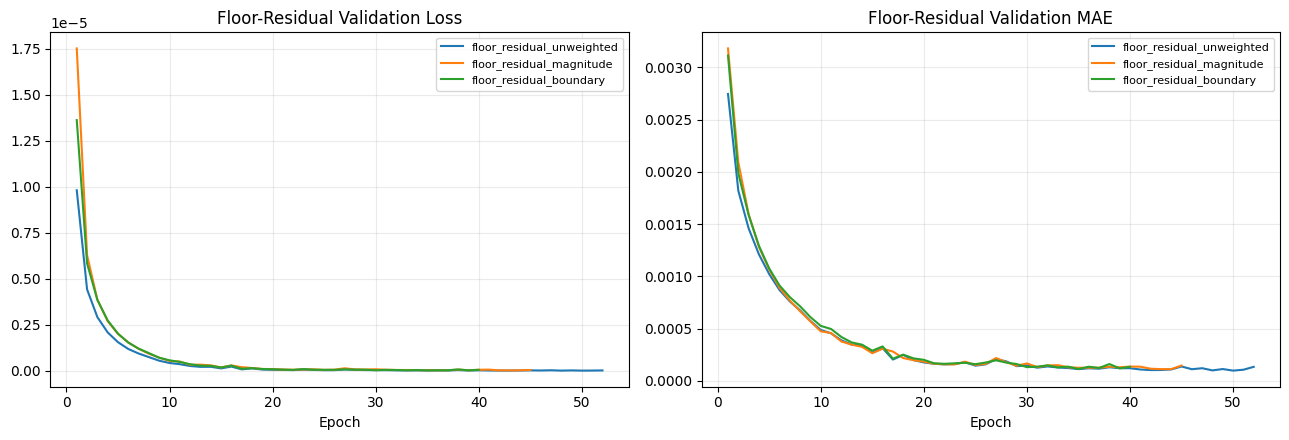

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name in floor_candidates:
    history = candidate_results[name]["history"]
    axes[0].plot(history["epoch"], history["validation_loss"], label=name)
    axes[1].plot(history["epoch"], history["validation_mae"], label=name)
axes[0].set_title("Floor-Residual Validation Loss")
axes[1].set_title("Floor-Residual Validation MAE")
for axis in axes:
    axis.set_xlabel("Epoch")
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)
plt.tight_layout()
plt.show()

# 9. Segmented and boundary-region analysis

The constrained model is evaluated across exercise status, moneyness, and proximity to the exercise boundary. This determines whether aggregate accuracy is achieved at the expense of the economically difficult transition region.

In [14]:
test_frame["exercise_region"] = np.where(
    test_frame["exercise_now"], "exercise", "continue"
)
test_frame["boundary_bucket"] = pd.cut(
    test_frame["boundary_distance_normalized"],
    bins=[-np.inf, 0.001, 0.005, 0.01, 0.05, np.inf],
    labels=["very close", "close", "near", "moderate", "far"],
)
test_frame["moneyness_bucket"] = pd.cut(
    test_frame["moneyness"],
    bins=[0.0, 0.75, 0.90, 1.10, 1.25, np.inf],
    labels=["deep ITM", "ITM", "near ATM", "OTM", "deep OTM"],
)

segmented_rows = []
for model_name, column in {
    "Direct MLP": "direct_mlp",
    "Non-negative premium": "nonnegative_premium",
    "Constrained floor residual": best_floor_candidate,
}.items():
    for segment_name in ("exercise_region", "boundary_bucket", "moneyness_bucket"):
        for segment, group in test_frame.groupby(segment_name, observed=True):
            segmented_rows.append({
                "model": model_name,
                "segment_type": segment_name,
                "segment": str(segment),
                **regression_metrics(
                    group["normalized_american_price"], group[column]
                ),
            })

segmented_results = pd.DataFrame(segmented_rows)
segmented_results.head(20)

,model,segment_type,segment,observations,mae,rmse,median_absolute_error,max_absolute_error,mean_error,r2,within_0.001,within_0.005,within_0.01,within_0.05
0,Direct MLP,exercise_region,continue,142651.0,0.000728,0.001073,0.000518,0.019201,3.586654e-05,0.999949,0.770741,0.995745,0.999713,1.0
1,Direct MLP,exercise_region,exercise,45160.0,0.000951,0.001348,0.000681,0.014359,-6.468777e-04,0.999894,0.650908,0.993091,0.999934,1.0
2,Direct MLP,boundary_bucket,very close,59673.0,0.000906,0.001301,0.000627,0.014359,-3.612198e-04,0.999944,0.673655,0.993464,0.999950,1.0
3,Direct MLP,boundary_bucket,close,14000.0,0.001057,0.001553,0.000708,0.011809,7.384595e-04,0.999924,0.622429,0.983643,0.999571,1.0
4,Direct MLP,boundary_bucket,near,7112.0,0.000916,0.001439,0.000586,0.014937,3.177461e-04,0.999935,0.682649,0.988048,0.998453,1.0
5,Direct MLP,boundary_bucket,moderate,33585.0,0.000869,0.001256,0.000642,0.019201,-2.096934e-04,0.999943,0.691767,0.994313,0.999315,1.0
6,Direct MLP,boundary_bucket,far,73441.0,0.000575,0.000774,0.000456,0.011382,-1.102547e-04,0.999958,0.848858,0.999673,0.999986,1.0
7,Direct MLP,moneyness_bucket,deep ITM,65461.0,0.000825,0.001090,0.000648,0.011382,-3.897501e-04,0.999802,0.684224,0.999236,0.999985,1.0
8,Direct MLP,moneyness_bucket,ITM,29422.0,0.000863,0.001183,0.000628,0.010490,-1.320045e-04,0.999751,0.683128,0.998063,0.999966,1.0
9,Direct MLP,moneyness_bucket,near ATM,32521.0,0.000946,0.001537,0.000564,0.019201,-9.629882e-05,0.999751,0.724732,0.980136,0.999231,1.0


# 10. Out-of-domain evaluation

The selected residual models are evaluated without retraining on all four out-of-domain components. Feature scaling remains frozen from Notebook 04.

In [15]:
ood_rows = []
for ood_name, path in OOD_PATHS.items():
    frame = read_parquet_components([path], columns=MODEL_COLUMNS, split=None)
    frame["normalized_intrinsic_value"] = frame["intrinsic_value"] / frame["strike"]
    frame["normalized_financial_floor"] = np.maximum(
        frame["normalized_european_price"], frame["normalized_intrinsic_value"]
    )
    frame["normalized_floor_residual"] = (
        frame["normalized_american_price"] - frame["normalized_financial_floor"]
    ).clip(lower=0.0)

    _, direct_loader = make_dataset_loader(
        frame, "normalized_american_price", shuffle=False
    )
    direct_pred = predict_regression_model(
        direct_model, direct_loader, device=DEVICE
    )
    frame = frame.merge(
        direct_pred[["sample_id", "prediction"]].rename(
            columns={"prediction": "Direct MLP"}
        ),
        on="sample_id",
        validate="one_to_one",
    )

    for candidate_name in ["nonnegative_premium", best_floor_candidate]:
        _, pred = predict_candidate(candidate_name, frame)
        frame = frame.merge(
            pred[["sample_id", "normalized_price_prediction"]].rename(
                columns={"normalized_price_prediction": candidate_name}
            ),
            on="sample_id",
            validate="one_to_one",
        )

    for model_name, column in {
        "Direct MLP": "Direct MLP",
        "Non-negative premium": "nonnegative_premium",
        "Constrained floor residual": best_floor_candidate,
    }.items():
        ood_rows.append({
            "ood_set": ood_name,
            "model": model_name,
            **regression_metrics(
                frame["normalized_american_price"], frame[column]
            ),
        })

ood_results = pd.DataFrame(ood_rows).set_index(["ood_set", "model"])
ood_results

observations       mae  \
ood_set           model                                                
high_volatility   Direct MLP                       50000.0  0.009221   
                  Non-negative premium             50000.0  0.000509   
                  Constrained floor residual       50000.0  0.000568   
extreme_moneyness Direct MLP                       50000.0  0.011993   
                  Non-negative premium             50000.0  0.000883   
                  Constrained floor residual       50000.0  0.000118   
long_maturity     Direct MLP                       50000.0  0.046026   
                  Non-negative premium             50000.0  0.009383   
                  Constrained floor residual       50000.0  0.003432   
rate_dividend     Direct MLP                       50000.0  0.011519   
                  Non-negative premium             50000.0  0.003789   
                  Constrained floor residual       50000.0  0.002961   

                                                  rmse  median_absolute_error  \
ood_set           model                                                         
high_volatility   Direct MLP                  0.014600               0.005074   
                  Non-negative premium        0.000819               0.000284   
                  Constrained floor residual  0.001110               0.000237   
extreme_moneyness Direct MLP                  0.020319               0.005079   
                  Non-negative premium        0.002012               0.000149   
                  Constrained floor residual  0.000378               0.000004   
long_maturity     Direct MLP                  0.087061               0.013083   
                  Non-negative premium        0.023525               0.001540   
                  Constrained floor residual  0.007965               0.000597   
rate_dividend     Direct MLP                  0.017558               0.006561   
                  Non-negative premium        0.007232               0.001428   
                  Constrained floor residual  0.006051               0.000551   

                                              max_absolute_error  mean_error  \
ood_set           model                                                        
high_volatility   Direct MLP                            0.112336   -0.000847   
                  Non-negative premium                  0.009030   -0.000332   
                  Constrained floor residual            0.011833    0.000383   
extreme_moneyness Direct MLP                            0.132883   -0.011816   
                  Non-negative premium                  0.022382   -0.000739   
                  Constrained floor residual            0.011095   -0.000006   
long_maturity     Direct MLP                            0.435759   -0.042267   
                  Non-negative premium                  0.287656   -0.008110   
                  Constrained floor residual            0.083836   -0.000913   
rate_dividend     Direct MLP                            0.089304    0.002272   
                  Non-negative premium                  0.082901   -0.001858   
                  Constrained floor residual            0.048240   -0.002685   

                                                    r2  within_0.001  \
ood_set           model                                                
high_volatility   Direct MLP                  0.989659       0.14632   
                  Non-negative premium        0.999967       0.85390   
                  Constrained floor residual  0.999940       0.84976   
extreme_moneyness Direct MLP                  0.995443       0.25694   
                  Non-negative premium        0.999955       0.78832   
                  Constrained floor residual  0.999998       0.98090   
long_maturity     Direct MLP                  0.703781       0.11320   
                  Non-negative premium        0.978371       0.42366   
                  Constrained floor residual  0.997521       

# 11. Inference-speed comparison

Residual models have approximately the same network capacity as the direct MLP. Their principal computational advantage is therefore expected to remain similar: a forward pass replaces repeated CRR backward induction.

In [16]:
@torch.inference_mode()
def benchmark_model(model, feature_tensor, *, repeats=5):
    model.eval()
    feature_tensor = feature_tensor.to(DEVICE)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    timings = []
    for _ in range(repeats):
        started = time.perf_counter()
        _ = model(feature_tensor)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        timings.append(time.perf_counter() - started)
    median = float(np.median(timings))
    return {
        "observations": len(feature_tensor),
        "median_seconds": median,
        "observations_per_second": len(feature_tensor) / median,
    }

benchmark_dataset, _ = make_dataset_loader(
    test_frame, "normalized_american_price", shuffle=False
)
benchmark_features = benchmark_dataset.features[: min(100_000, len(benchmark_dataset))]

speed_rows = []
for model_name, model in {
    "Direct MLP": direct_model,
    "Non-negative premium": selected_models["nonnegative_premium"],
    "Constrained floor residual": selected_models[best_floor_candidate],
}.items():
    speed_rows.append({"model": model_name, **benchmark_model(model, benchmark_features)})

speed_results = pd.DataFrame(speed_rows).set_index("model")
speed_results

,observations,median_seconds,observations_per_second
model,,,
Direct MLP,100000,0.001228,8.141771e+07
Non-negative premium,100000,0.001230,8.129454e+07
Constrained floor residual,100000,0.001222,8.185349e+07


# 12. Formal hypothesis decisions

The decision rules were fixed before viewing the test results:

- H2 requires at least a 1% relative MAE improvement over the direct MLP;
- H3 requires fewer financial-bound violations without more than 2% relative MAE degradation compared with the unconstrained premium model.

In [17]:
h2_decision = decide_h2_premium_decomposition(
    comparison,
    direct_model="Direct MLP",
    premium_model="Non-negative premium",
    minimum_relative_mae_improvement=0.01,
)
h3_decision = decide_h3_financial_constraints(
    comparison,
    unconstrained_model="Unconstrained premium",
    constrained_model="Constrained floor residual",
    maximum_relative_mae_degradation=0.02,
)

hypothesis_decisions = {
    "H2": h2_decision.to_dict(),
    "H3": h3_decision.to_dict(),
}
hypothesis_decisions

{'H2': {'hypothesis': 'H2 — Premium decomposition',
  'decision': 'supported',
  'rationale': 'The premium model exceeds the predefined MAE improvement threshold.',
  'evidence': {'direct_mae': 0.0007816734844188249,
   'premium_mae': 0.0002050542917012715,
   'relative_mae_improvement': 0.7376727037712817,
   'required_improvement': 0.01}},
 'H3': {'hypothesis': 'H3 — Financial constraints',
  'decision': 'supported',
  'rationale': 'The constrained model reduces financial-bound violations without exceeding the predefined MAE degradation tolerance.',
  'evidence': {'unconstrained_violations': 64563.0,
   'constrained_violations': 0.0,
   'unconstrained_mae': 0.0002125995245248974,
   'constrained_mae': 0.00010186947988981782,
   'relative_mae_degradation': -0.520838627849857,
   'allowed_degradation': 0.02}}}

In [18]:
comparison.to_csv(PREMIUM_ARTIFACT_DIR / "model_comparison.csv")
premium_comparison.to_csv(PREMIUM_ARTIFACT_DIR / "premium_comparison.csv")
segmented_results.to_csv(PREMIUM_ARTIFACT_DIR / "segmented_results.csv", index=False)
ood_results.to_csv(PREMIUM_ARTIFACT_DIR / "ood_results.csv")
speed_results.to_csv(PREMIUM_ARTIFACT_DIR / "speed_results.csv")
save_json(hypothesis_decisions, PREMIUM_ARTIFACT_DIR / "hypothesis_decisions.json")
save_json(
    {
        "best_floor_candidate": best_floor_candidate,
        "material_premium_threshold": material_threshold,
        "fast_dev_mode": FAST_DEV_MODE,
    },
    PREMIUM_ARTIFACT_DIR / "evaluation_summary.json",
)

PosixPath('/storage/deep_learning_american_option_pricing/artifacts/premium_models/evaluation_summary.json')

# 13. Interpretation framework

The empirical interpretation must separate three questions:

1. **Approximation accuracy:** Does residual learning improve the final American price?
2. **Premium learning:** Does the model identify economically material early-exercise value rather than defaulting to zero?
3. **Financial validity:** Are lower-bound violations eliminated without an unacceptable accuracy trade-off?

A constrained model may be preferable even if its aggregate MAE is marginally worse, provided that the degradation is economically small and invalid prices are materially reduced. Conversely, a mathematically constrained model should not be declared superior solely because it cannot violate a bound; it must still approximate the benchmark accurately across the full domain and near the stopping boundary.

# 14. Limitations

- The residual targets are generated from the same CRR framework as the direct target.
- Weighting rules encode research priorities and may shift error between regions.
- `Softplus` guarantees non-negative residuals but does not enforce every monotonicity property.
- Boundary distance is available because the synthetic pricing engine exposes continuation value; this information would be harder to observe in real market data.
- The out-of-domain analysis remains model-based and does not establish real-market robustness.
- Multiple candidate trainings increase computational cost and create a limited model-selection layer that must remain confined to validation results.

# 15. References used in this notebook

Black, F., & Scholes, M. (1973). The pricing of options and corporate liabilities. *Journal of Political Economy, 81*(3), 637–654.

Cox, J. C., Ross, S. A., & Rubinstein, M. (1979). Option pricing: A simplified approach. *Journal of Financial Economics, 7*(3), 229–263.

Elbayed, Z., & Qadi El Idrissi, A. (2025). Deep learning in financial modeling: Predicting European put option prices with neural networks. *Algorithms, 18*(3), 161.

Pu, V. R. H. (2021). *Pricing options using deep neural networks from a practical perspective* [Master’s thesis, Imperial College London].

The final bibliography and citation audit remain maintained in the project-level `references/` directory.

# 16. Development checkpoint

Notebook 05 completes the direct-versus-residual pricing comparison and provides formal decisions for H2 and H3. The next stage will focus on explicit exercise-boundary learning through a multi-task regression and classification model.